# Magnetic Field Models in Geopack (Scalar + Vectorized)


This notebook is a practical guide to using:


**External (magnetospheric) models (Tsyganenko):**

- **T89**, **T96**, **T01**, **T04**


**Internal (geomagnetic) field models:**

- **Dipole** via `geopack.dip(x, y, z)`  *(GSM; vectorized supported)*

- **IGRF** via `geopack.igrf_gsm(_vectorized)` and `geopack.igrf_gsw(_vectorized)`


---

## Key idea: External vs Total Field


Tsyganenko models return the **EXTERNAL** field only:


$$\mathbf{B}_{\text{total}} = \mathbf{B}_{\text{internal}} + \mathbf{B}_{\text{external}}$$


In this notebook, **positions are GSM by default** (Earth radii, Re).

If you select IGRF as the internal model for TOTAL, we use **IGRF in GSM** (`igrf_gsm`)

to keep coordinates consistent with Tsyganenko outputs.


---

## Notes on IGRF practical domain


IGRF is an internal-field model; in many workflows you mainly use it at/above the surface.

We include a practical lower bound:

- **r >= 1.0 Re**


and we keep an optional upper bound knob (default: None = no upper cap).

If you want a "typical" demo range, set IGRF_RMAX_DEMO = 20.0.

## 1) Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import pandas as pd
import time
from datetime import datetime
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

from mageometry import geopack
from mageometry.geopack import recalc, dip  # convenience

from IPython.display import display

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

print("Environment")
import sys
print("  python:", sys.version.split()[0])
print("  numpy :", np.__version__)
print("  float eps:", np.finfo(np.float64).eps)


Load IGRF coefficients ...
Environment
  python: 3.11.1
  numpy : 2.2.6
  float eps: 2.220446049250313e-16


### Notebook-wide knobs

In [2]:
# ---- IGRF domain knobs ----
IGRF_RMIN = 1.0          # at/above surface
IGRF_RMAX_DEMO = None    # e.g., 20.0 for a "typical" magnetospheric demo; None disables upper cap

# ---- Tsyganenko domain masking ----
# (T/T04 models are valid only for X > -15 Re)
ENFORCE_TS_DOMAIN = True


## 2) Model Overview


**External field (Tsyganenko) models:**

- **T89**: parameterized by Kp (7 discrete levels via `iopt`)

- **T96**: solar wind pressure + IMF By/Bz + Dst

- **T01**: storm-time enhancements (adds G1/G2)

- **T04**: most comprehensive storm-time model (adds W1..W6)


**Internal field models:**

- **Dipole** (`dip`) is simple and fast (GSM)

- **IGRF** is a spherical-harmonic internal model (available in GSM/GSW in this library)


**Important:** Tsyganenko models output EXTERNAL only.

Physical total field requires adding an internal model.

## 3) Parameters

In [3]:
# T89: iopt = 1..7 (Kp levels)
kp_values = {
    1: "Kp = 0, 0+",
    2: "Kp = 1-, 1, 1+",
    3: "Kp = 2-, 2, 2+",
    4: "Kp = 3-, 3, 3+",
    5: "Kp = 4-, 4, 4+",
    6: "Kp = 5-, 5, 5+",
    7: "Kp >= 6-",
}
print("T89: iopt meaning")
for k, v in kp_values.items():
    print(f"  iopt={k}: {v}")

print("\nT96 parmod (len=10)")
print("  parmod[0] = Pdyn (nPa)")
print("  parmod[1] = Dst (nT)")
print("  parmod[2] = ByIMF (nT)")
print("  parmod[3] = BzIMF (nT)")
print("  parmod[4:10] unused (0)")

print("\nT01 parmod")
print("  T96 base + parmod[4]=G1, parmod[5]=G2")

print("\nT04 parmod")
print("  T96 base + parmod[4:10]=W1..W6")


T89: iopt meaning
  iopt=1: Kp = 0, 0+
  iopt=2: Kp = 1-, 1, 1+
  iopt=3: Kp = 2-, 2, 2+
  iopt=4: Kp = 3-, 3, 3+
  iopt=5: Kp = 4-, 4, 4+
  iopt=6: Kp = 5-, 5, 5+
  iopt=7: Kp >= 6-

T96 parmod (len=10)
  parmod[0] = Pdyn (nPa)
  parmod[1] = Dst (nT)
  parmod[2] = ByIMF (nT)
  parmod[3] = BzIMF (nT)
  parmod[4:10] unused (0)

T01 parmod
  T96 base + parmod[4]=G1, parmod[5]=G2

T04 parmod
  T96 base + parmod[4:10]=W1..W6


## 4) Helpers (internal / external / total)


Conventions:

- Inputs (x,y,z) are **GSM** unless you explicitly use IGRF_GSW calls.

- For TOTAL, keep internal and external in the same coordinate system.

  Here we default to IGRF_GSM when internal_model="igrf".

In [4]:
def _as_float64(a):
    return np.asarray(a, dtype=np.float64)

def _is_arraylike(x):
    return np.ndim(x) > 0

def _norm3(bx, by, bz):
    return np.sqrt(bx*bx + by*by + bz*bz)

def _resolve(name):
    return getattr(geopack, name, None)

def internal_field(model, x, y, z, coord="gsm", r_min=1.0, r_max=None):
    """
    Internal magnetic field.

    Parameters
    ----------
    model : str
        "dipole" or "igrf"
    x, y, z : float or ndarray
        Position in Earth radii (Re).
    coord : str
        For IGRF only: "gsm" or "gsw". (Dipole is GSM in geopack.)
    r_min : float
        Practical lower radius bound. Points with r < r_min -> NaN (IGRF only).
    r_max : float or None
        Optional upper bound for IGRF demo usage. Points with r > r_max -> NaN (if provided).

    Returns
    -------
    bx, by, bz : float or ndarray
        Field components in nT.
    """
    model = model.lower().strip()
    coord = coord.lower().strip()

    x64, y64, z64 = _as_float64(x), _as_float64(y), _as_float64(z)
    vec = _is_arraylike(x64) or _is_arraylike(y64) or _is_arraylike(z64)

    if model in ("dip", "dipole"):
        return dip(x64, y64, z64)

    if model == "igrf":
        if coord == "gsm":
            f_vec = _resolve("igrf_gsm_vectorized")
            f_sca = _resolve("igrf_gsm")
        elif coord == "gsw":
            f_vec = _resolve("igrf_gsw_vectorized")
            f_sca = _resolve("igrf_gsw")
        else:
            raise ValueError("coord must be 'gsm' or 'gsw' for IGRF")

        if f_sca is None and f_vec is None:
            raise RuntimeError("IGRF functions not found in geopack namespace.")

        r = _norm3(x64, y64, z64)
        ok = (r >= r_min)
        if r_max is not None:
            ok = ok & (r <= r_max)

        if vec:
            bx = np.full_like(x64, np.nan, dtype=np.float64)
            by = np.full_like(y64, np.nan, dtype=np.float64)
            bz = np.full_like(z64, np.nan, dtype=np.float64)

            if f_vec is not None:
                bx_ok, by_ok, bz_ok = f_vec(x64[ok], y64[ok], z64[ok])
                bx[ok] = _as_float64(bx_ok)
                by[ok] = _as_float64(by_ok)
                bz[ok] = _as_float64(bz_ok)
            else:
                # scalar fallback
                idx = np.where(ok.ravel())[0]
                for i in idx:
                    bxi, byi, bzi = f_sca(float(x64.ravel()[i]), float(y64.ravel()[i]), float(z64.ravel()[i]))
                    bx.ravel()[i] = bxi
                    by.ravel()[i] = byi
                    bz.ravel()[i] = bzi
            return bx, by, bz

        # scalar
        if not bool(ok):
            return (np.nan, np.nan, np.nan)
        if f_sca is not None:
            return f_sca(float(x64), float(y64), float(z64))
        bx1, by1, bz1 = f_vec(np.array([x64]), np.array([y64]), np.array([z64]))
        return (float(bx1[0]), float(by1[0]), float(bz1[0]))

    raise ValueError(f"Unknown internal field model: {model}")

def tsyganenko_external(ts_model, params, ps, x, y, z, enforce_domain=False):
    """
    Tsyganenko EXTERNAL field only in GSM.

    You requested to see x < -15 too. Therefore by default enforce_domain=False,
    i.e. **no masking** is applied.

    Returns
    -------
    bx, by, bz : float or ndarray (nT)
    """
    ts_model = ts_model.lower().strip()
    x64, y64, z64 = _as_float64(x), _as_float64(y), _as_float64(z)
    vec = _is_arraylike(x64) or _is_arraylike(y64) or _is_arraylike(z64)

    if ts_model == "t89":
        f_vec = _resolve("t89_vectorized")
        f_sca = _resolve("t89")
    elif ts_model == "t96":
        f_vec = _resolve("t96_vectorized")
        f_sca = _resolve("t96")
    elif ts_model == "t01":
        f_vec = _resolve("t01_vectorized")
        f_sca = _resolve("t01")
    elif ts_model == "t04":
        f_vec = _resolve("t04_vectorized")
        f_sca = _resolve("t04")
    else:
        raise ValueError(f"Unknown Tsyganenko model: {ts_model}")

    if f_vec is None and f_sca is None:
        raise RuntimeError(f"Model function not found in geopack namespace: {ts_model}")

    if not vec:
        return f_sca(params, ps, float(x64), float(y64), float(z64))

    if f_vec is not None:
        if enforce_domain and ts_model in ("t01", "t04"):
            # --- domain mask example (tail cutoff) ---
            # You can extend this rule set as needed.
            ok = (x64 >= -15.0)

            bx = np.full_like(x64, np.nan, dtype=np.float64)
            by = np.full_like(y64, np.nan, dtype=np.float64)
            bz = np.full_like(z64, np.nan, dtype=np.float64)

            if np.any(ok):
                bx_ok, by_ok, bz_ok = f_vec(params, ps, x64[ok], y64[ok], z64[ok])
                bx[ok] = _as_float64(bx_ok)
                by[ok] = _as_float64(by_ok)
                bz[ok] = _as_float64(bz_ok)
            return bx, by, bz

        # default: no masking
        bx, by, bz = f_vec(params, ps, x64, y64, z64)
        return _as_float64(bx), _as_float64(by), _as_float64(bz)

    # Scalar fallback
    outx = np.empty_like(x64, dtype=np.float64)
    outy = np.empty_like(y64, dtype=np.float64)
    outz = np.empty_like(z64, dtype=np.float64)
    for i in range(x64.size):
        bxi, byi, bzi = f_sca(params, ps, float(x64.ravel()[i]), float(y64.ravel()[i]), float(z64.ravel()[i]))
        outx.ravel()[i] = bxi
        outy.ravel()[i] = byi
        outz.ravel()[i] = bzi
    return outx, outy, outz

def total_field(internal_model, ts_model, ts_params, ps, x, y, z,
                internal_coord="gsm", igrf_rmin=1.0, igrf_rmax=None,
                enforce_domain=False):
    """
    TOTAL field = INTERNAL + EXTERNAL.

    If internal_model == "igrf", keep internal_coord="gsm" for consistency with Tsyganenko (GSM).
    """
    bx_int, by_int, bz_int = internal_field(
        internal_model, x, y, z, coord=internal_coord, r_min=igrf_rmin, r_max=igrf_rmax
    )
    bx_ext, by_ext, bz_ext = tsyganenko_external(
        ts_model, ts_params, ps, x, y, z, enforce_domain=enforce_domain
    )
    return (bx_int + bx_ext, by_int + by_ext, bz_int + bz_ext,
            bx_int, by_int, bz_int, bx_ext, by_ext, bz_ext)


## 5) Initialize geopack (time / tilt / IGRF coeffs)

In [5]:
ut = datetime(2015, 3, 17, 12, 0, 0).timestamp()
ps = recalc(ut)

print(f"Time UTC: {datetime.utcfromtimestamp(ut)}")
print(f"Dipole tilt ps: {ps:.6f} rad = {np.degrees(ps):.2f} deg")
print(f"ENFORCE_TS_DOMAIN = {ENFORCE_TS_DOMAIN}")
print(f"IGRF_RMIN={IGRF_RMIN}, IGRF_RMAX_DEMO={IGRF_RMAX_DEMO}")


Time UTC: 2015-03-17 03:00:00
Dipole tilt ps: -0.172710 rad = -9.90 deg
ENFORCE_TS_DOMAIN = True
IGRF_RMIN=1.0, IGRF_RMAX_DEMO=None


## 6) Basic Usage (single point)


- internal-only

- external-only

- total = internal + external

In [6]:
x_gsm, y_gsm, z_gsm = -6.0, 3.0, 2.0

internal_model = "dipole"      # try "igrf"
igrf_coord_for_total = "gsm"   # keep GSM for TOTAL

print(f"Position (GSM): ({x_gsm}, {y_gsm}, {z_gsm}) Re")
print(f"Internal model: {internal_model} (coord={igrf_coord_for_total if internal_model=='igrf' else 'gsm'})")
print("=" * 70)

bx_i, by_i, bz_i = internal_field(internal_model, x_gsm, y_gsm, z_gsm,
                                  coord=igrf_coord_for_total,
                                  r_min=IGRF_RMIN, r_max=IGRF_RMAX_DEMO)
print("Internal-only:")
print(f"  B = ({bx_i:.3f}, {by_i:.3f}, {bz_i:.3f}) nT   |B|={float(_norm3(bx_i,by_i,bz_i)):.3f} nT")

# T89 example
iopt = 4
bx_e, by_e, bz_e = tsyganenko_external("t89", iopt, ps, x_gsm, y_gsm, z_gsm, enforce_domain=ENFORCE_TS_DOMAIN)
print("\nT89 external-only:")
print(f"  B = ({bx_e:.3f}, {by_e:.3f}, {bz_e:.3f}) nT   |B|={float(_norm3(bx_e,by_e,bz_e)):.3f} nT")

bx_t, by_t, bz_t, *_ = total_field(internal_model, "t89", iopt, ps, x_gsm, y_gsm, z_gsm,
                                   internal_coord=igrf_coord_for_total,
                                   igrf_rmin=IGRF_RMIN, igrf_rmax=IGRF_RMAX_DEMO,
                                   enforce_domain=ENFORCE_TS_DOMAIN)
print("T89 TOTAL (internal + external):")
print(f"  B = ({bx_t:.3f}, {by_t:.3f}, {bz_t:.3f}) nT   |B|={float(_norm3(bx_t,by_t,bz_t)):.3f} nT")

# T96 example
parmod96 = np.zeros(10, dtype=np.float64)
parmod96[0] = 3.0
parmod96[1] = -50.0
parmod96[2] = 0.0
parmod96[3] = -5.0

bx_e, by_e, bz_e = tsyganenko_external("t96", parmod96, ps, x_gsm, y_gsm, z_gsm, enforce_domain=ENFORCE_TS_DOMAIN)
print("\nT96 external-only:")
print(f"  B = ({bx_e:.3f}, {by_e:.3f}, {bz_e:.3f}) nT   |B|={float(_norm3(bx_e,by_e,bz_e)):.3f} nT")

bx_t, by_t, bz_t, *_ = total_field(internal_model, "t96", parmod96, ps, x_gsm, y_gsm, z_gsm,
                                   internal_coord=igrf_coord_for_total,
                                   igrf_rmin=IGRF_RMIN, igrf_rmax=IGRF_RMAX_DEMO,
                                   enforce_domain=ENFORCE_TS_DOMAIN)
print("T96 TOTAL (internal + external):")
print(f"  B = ({bx_t:.3f}, {by_t:.3f}, {bz_t:.3f}) nT   |B|={float(_norm3(bx_t,by_t,bz_t)):.3f} nT")


Position (GSM): (-6.0, 3.0, 2.0) Re
Internal model: dipole (coord=gsm)
Internal-only:
  B = (81.034, -47.999, 53.775) nT   |B|=108.453 nT

T89 external-only:
  B = (34.735, -12.734, -29.490) nT   |B|=47.311 nT
T89 TOTAL (internal + external):
  B = (115.769, -60.733, 24.285) nT   |B|=132.969 nT

T96 external-only:
  B = (53.618, -22.080, -39.397) nT   |B|=70.104 nT
T96 TOTAL (internal + external):
  B = (134.652, -70.079, 14.378) nT   |B|=152.476 nT


### (Optional) IGRF in GSM vs GSW at a single point


GSM and GSW differ. Use the one consistent with your workflow.

In [7]:
bx_gsm, by_gsm, bz_gsm = internal_field("igrf", x_gsm, y_gsm, z_gsm, coord="gsm",
                                       r_min=IGRF_RMIN, r_max=IGRF_RMAX_DEMO)
bx_gsw, by_gsw, bz_gsw = internal_field("igrf", x_gsm, y_gsm, z_gsm, coord="gsw",
                                       r_min=IGRF_RMIN, r_max=IGRF_RMAX_DEMO)

print("IGRF at the same numeric coordinates (demo only):")
print(f"  IGRF_GSM: ({bx_gsm:.3f}, {by_gsm:.3f}, {bz_gsm:.3f}) nT")
print(f"  IGRF_GSW: ({bx_gsw:.3f}, {by_gsw:.3f}, {bz_gsw:.3f}) nT")


IGRF at the same numeric coordinates (demo only):
  IGRF_GSM: (79.700, -45.466, 53.131) nT
  IGRF_GSW: (79.700, -45.466, 53.131) nT


## 7) Vectorized Usage on a Grid (TOTAL field)


Visualization style:

- Left: |B_total| [nT] (log scale)

- Right: direction unit vectors (quiver), colored by |B_total| (log)

In [8]:
nx, nz = 60, 50
x_range = np.linspace(-20, 12, nx)
z_range = np.linspace(-12, 12, nz)
X, Z = np.meshgrid(x_range, z_range)
Y = np.zeros_like(X)

x_flat = X.ravel()
y_flat = Y.ravel()
z_flat = Z.ravel()

internal_model_grid = "dipole"   # try "igrf"
igrf_coord_for_total = "gsm"

parmod = np.zeros(10, dtype=np.float64)
parmod[0] = 5.0
parmod[1] = -100.0
parmod[2] = 3.0
parmod[3] = -10.0

start = time.time()
bx_tot, by_tot, bz_tot, bx_int, by_int, bz_int, bx_ext, by_ext, bz_ext = total_field(
    internal_model_grid, "t96", parmod, ps, x_flat, y_flat, z_flat,
    internal_coord=igrf_coord_for_total,
    igrf_rmin=IGRF_RMIN, igrf_rmax=IGRF_RMAX_DEMO,
    enforce_domain=ENFORCE_TS_DOMAIN
)
elapsed = time.time() - start

bmag = _norm3(bx_tot, by_tot, bz_tot)
Bmag = bmag.reshape(nz, nx)
Bx = bx_tot.reshape(nz, nx)
Bz = bz_tot.reshape(nz, nx)

print(f"Computed TOTAL field on grid: n={x_flat.size} points in {elapsed:.3f}s")
print(f"Rate: {x_flat.size/elapsed:.0f} points/s")
print(f"|B| range (nT): min={np.nanmin(Bmag):.2f}, max={np.nanmax(Bmag):.2f}")


Computed TOTAL field on grid: n=3000 points in 0.279s
Rate: 10761 points/s
|B| range (nT): min=4.44, max=3626836.34


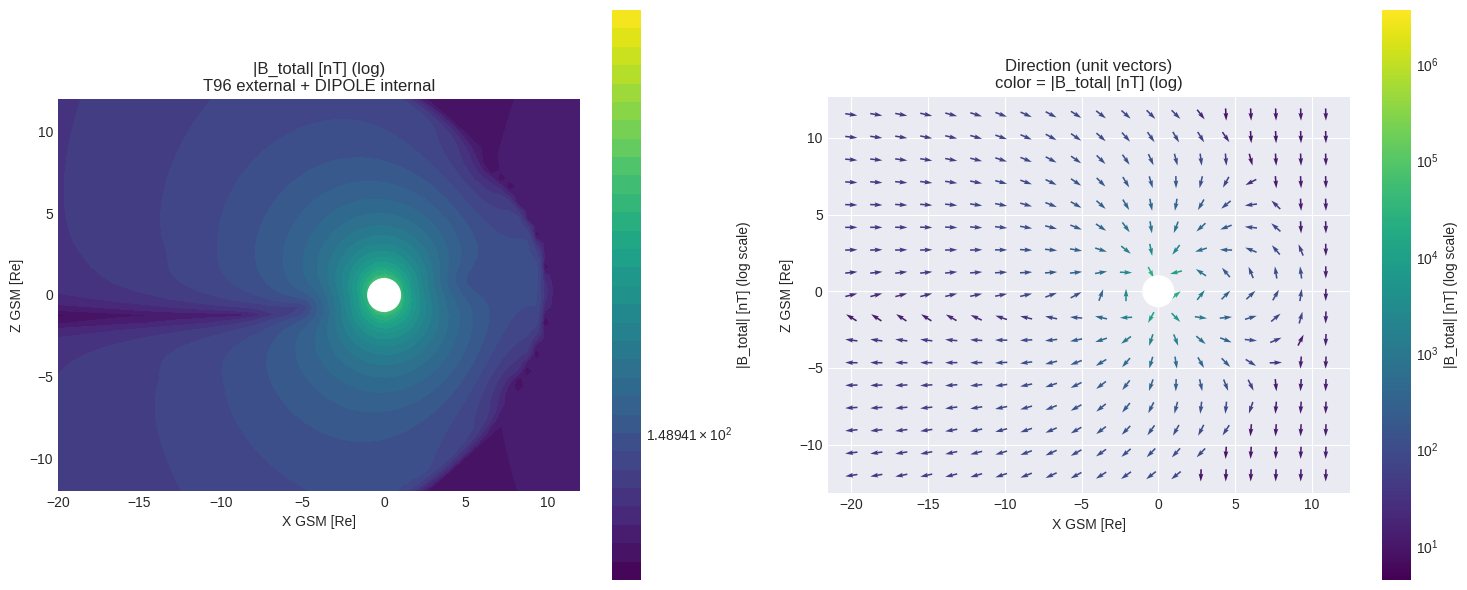

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

pos = Bmag[np.isfinite(Bmag) & (Bmag > 0)]
bmin = np.nanmin(pos) if pos.size else 1e-3
bmax = np.nanmax(Bmag) if np.isfinite(Bmag).any() else 1.0
levels = np.logspace(np.log10(bmin), np.log10(bmax), 32)

im = ax1.contourf(
    X, Z, Bmag, levels=levels, cmap="viridis",
    norm=matplotlib.colors.LogNorm(vmin=bmin, vmax=bmax)
)
ax1.set_xlabel("X GSM [Re]")
ax1.set_ylabel("Z GSM [Re]")
ax1.set_title(f"|B_total| [nT] (log)\nT96 external + {internal_model_grid.upper()} internal")
ax1.set_aspect("equal")
earth = plt.Circle((0, 0), 1, color="white", zorder=10)
ax1.add_patch(earth)
cbar = plt.colorbar(im, ax=ax1)
cbar.set_label("|B_total| [nT] (log scale)")

skip = 3
Xs = X[::skip, ::skip]
Zs = Z[::skip, ::skip]
Bx_s = Bx[::skip, ::skip]
Bz_s = Bz[::skip, ::skip]
Bm_s = np.sqrt(Bx_s**2 + Bz_s**2)

eps = 1e-12
Ux = Bx_s / (Bm_s + eps)
Uz = Bz_s / (Bm_s + eps)
arrow_len = 0.8
U = arrow_len * Ux
V = arrow_len * Uz

C = Bmag[::skip, ::skip]
q = ax2.quiver(
    Xs, Zs, U, V, C, cmap="viridis",
    norm=matplotlib.colors.LogNorm(vmin=bmin, vmax=bmax),
    angles="xy", scale_units="xy", scale=1, pivot="mid", width=0.003
)
ax2.set_xlabel("X GSM [Re]")
ax2.set_ylabel("Z GSM [Re]")
ax2.set_title("Direction (unit vectors)\ncolor = |B_total| [nT] (log)")
ax2.set_aspect("equal")
earth2 = plt.Circle((0, 0), 1, color="white", zorder=10)
ax2.add_patch(earth2)
cbar2 = plt.colorbar(q, ax=ax2)
cbar2.set_label("|B_total| [nT] (log scale)")

plt.tight_layout()
plt.show()


## 8) Model Comparison Along the Sun–Earth Line (TOTAL field)

In [10]:
x_line = np.linspace(-25, 12, 260)
y_line = np.zeros_like(x_line)
z_line = np.zeros_like(x_line)

internal_model_cmp = "dipole"  # try "igrf"
igrf_coord_for_total = "gsm"

bx_i, by_i, bz_i = internal_field(internal_model_cmp, x_line, y_line, z_line,
                                  coord=igrf_coord_for_total,
                                  r_min=IGRF_RMIN, r_max=IGRF_RMAX_DEMO)
b_int = _norm3(bx_i, by_i, bz_i)

iopt_t89 = 4

par_storm = np.zeros(10, dtype=np.float64)
par_storm[0] = 3.0
par_storm[1] = -50.0
par_storm[2] = 0.0
par_storm[3] = -5.0

par_t01 = par_storm.copy()
par_t01[4] = 2.0
par_t01[5] = 3.0

par_t04 = par_storm.copy()
par_t04[4:10] = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

bx_e89, by_e89, bz_e89 = tsyganenko_external("t89", iopt_t89, ps, x_line, y_line, z_line, enforce_domain=ENFORCE_TS_DOMAIN)
bx_e96, by_e96, bz_e96 = tsyganenko_external("t96", par_storm, ps, x_line, y_line, z_line, enforce_domain=ENFORCE_TS_DOMAIN)
bx_e01, by_e01, bz_e01 = tsyganenko_external("t01", par_t01, ps, x_line, y_line, z_line, enforce_domain=ENFORCE_TS_DOMAIN)
bx_e04, by_e04, bz_e04 = tsyganenko_external("t04", par_t04, ps, x_line, y_line, z_line, enforce_domain=ENFORCE_TS_DOMAIN)

bx_89, by_89, bz_89 = bx_i + bx_e89, by_i + by_e89, bz_i + bz_e89
bx_96, by_96, bz_96 = bx_i + bx_e96, by_i + by_e96, bz_i + bz_e96
bx_01, by_01, bz_01 = bx_i + bx_e01, by_i + by_e01, bz_i + bz_e01
bx_04, by_04, bz_04 = bx_i + bx_e04, by_i + by_e04, bz_i + bz_e04

b_89 = _norm3(bx_89, by_89, bz_89)
b_96 = _norm3(bx_96, by_96, bz_96)
b_01 = _norm3(bx_01, by_01, bz_01)
b_04 = _norm3(bx_04, by_04, bz_04)


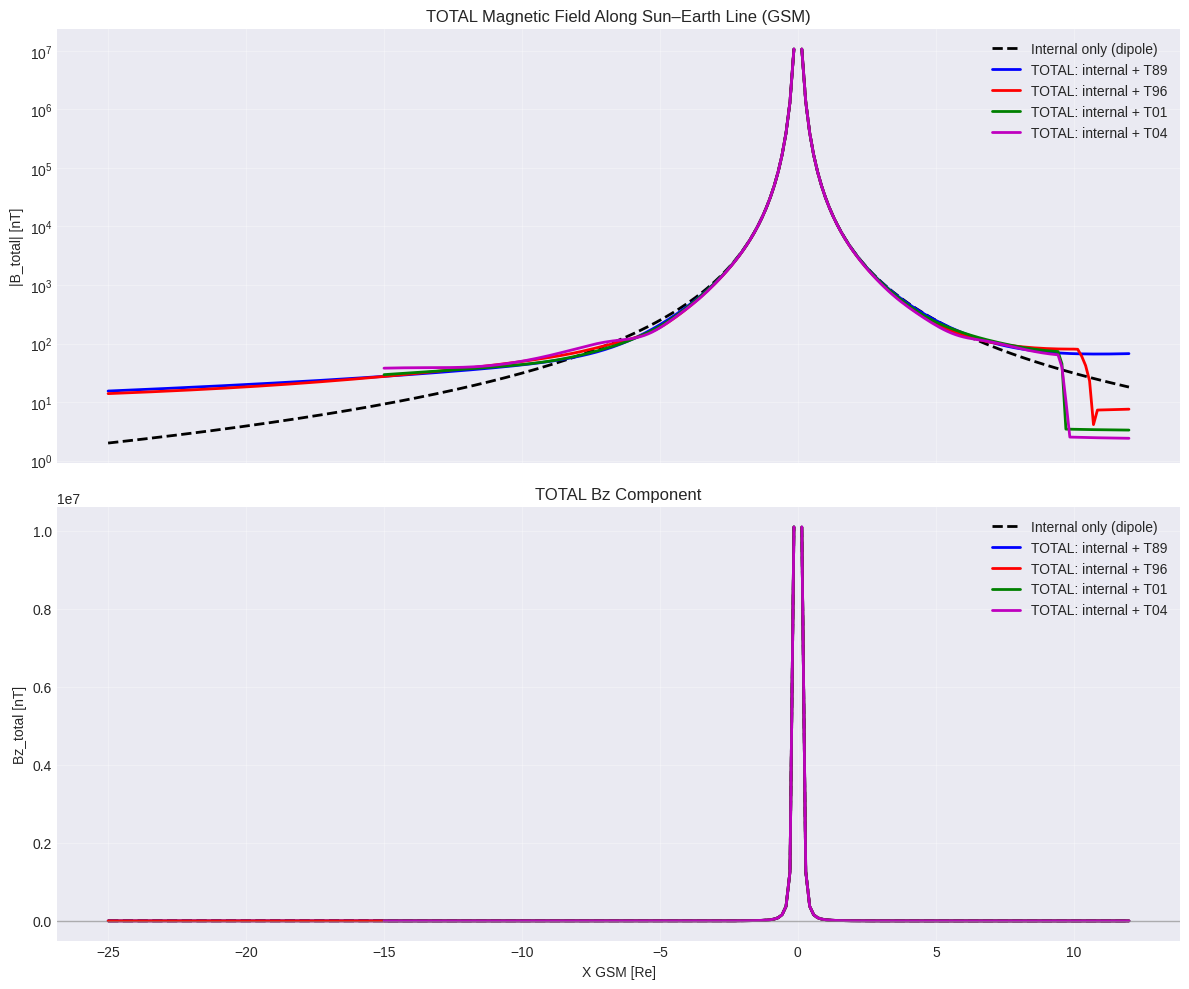

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.semilogy(x_line, b_int, "k--", lw=2, label=f"Internal only ({internal_model_cmp})")
ax1.semilogy(x_line, b_89, "b-", lw=2, label="TOTAL: internal + T89")
ax1.semilogy(x_line, b_96, "r-", lw=2, label="TOTAL: internal + T96")
ax1.semilogy(x_line, b_01, "g-", lw=2, label="TOTAL: internal + T01")
ax1.semilogy(x_line, b_04, "m-", lw=2, label="TOTAL: internal + T04")

ax1.set_ylabel("|B_total| [nT]")
ax1.set_title("TOTAL Magnetic Field Along Sun–Earth Line (GSM)")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

ax2.plot(x_line, bz_i, "k--", lw=2, label=f"Internal only ({internal_model_cmp})")
ax2.plot(x_line, bz_89, "b-", lw=2, label="TOTAL: internal + T89")
ax2.plot(x_line, bz_96, "r-", lw=2, label="TOTAL: internal + T96")
ax2.plot(x_line, bz_01, "g-", lw=2, label="TOTAL: internal + T01")
ax2.plot(x_line, bz_04, "m-", lw=2, label="TOTAL: internal + T04")

ax2.axhline(0, color="gray", lw=1, alpha=0.6)
ax2.set_xlabel("X GSM [Re]")
ax2.set_ylabel("Bz_total [nT]")
ax2.set_title("TOTAL Bz Component")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


## 9) Field Visualization (one figure per model; NO streamlines)


We plot for each model:

- Left: |B_total| [nT] (log scale)

- Right: unit-vector quiver colored by |B_total|


Models:

- Internal only (dipole or IGRF)

- TOTAL = internal + external (T89/T96/T01/T04)

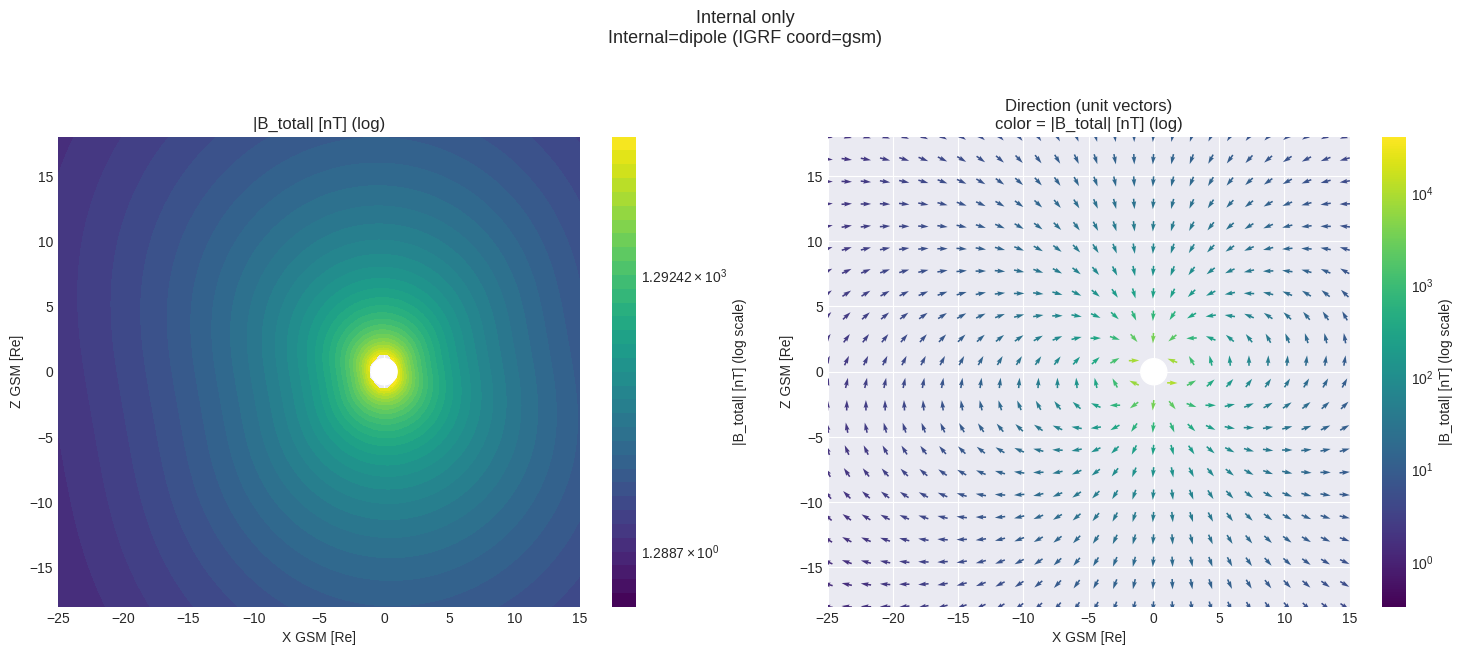

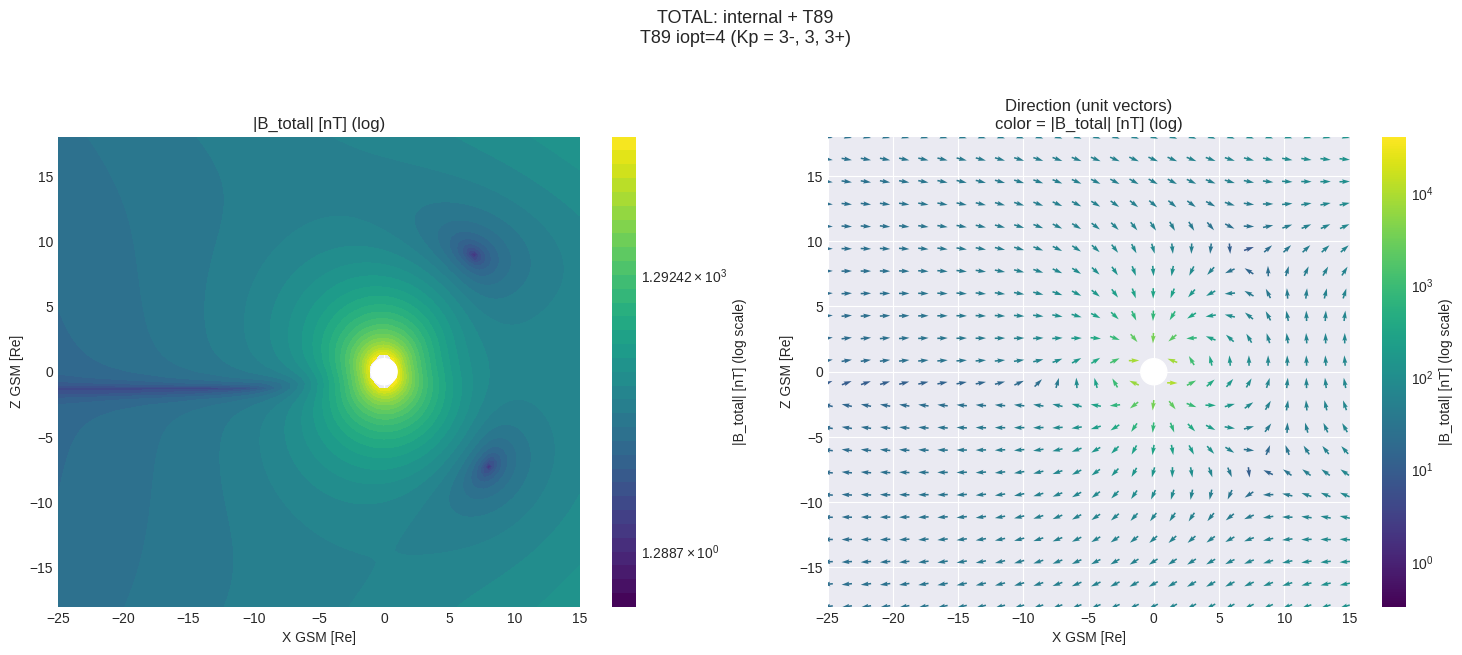

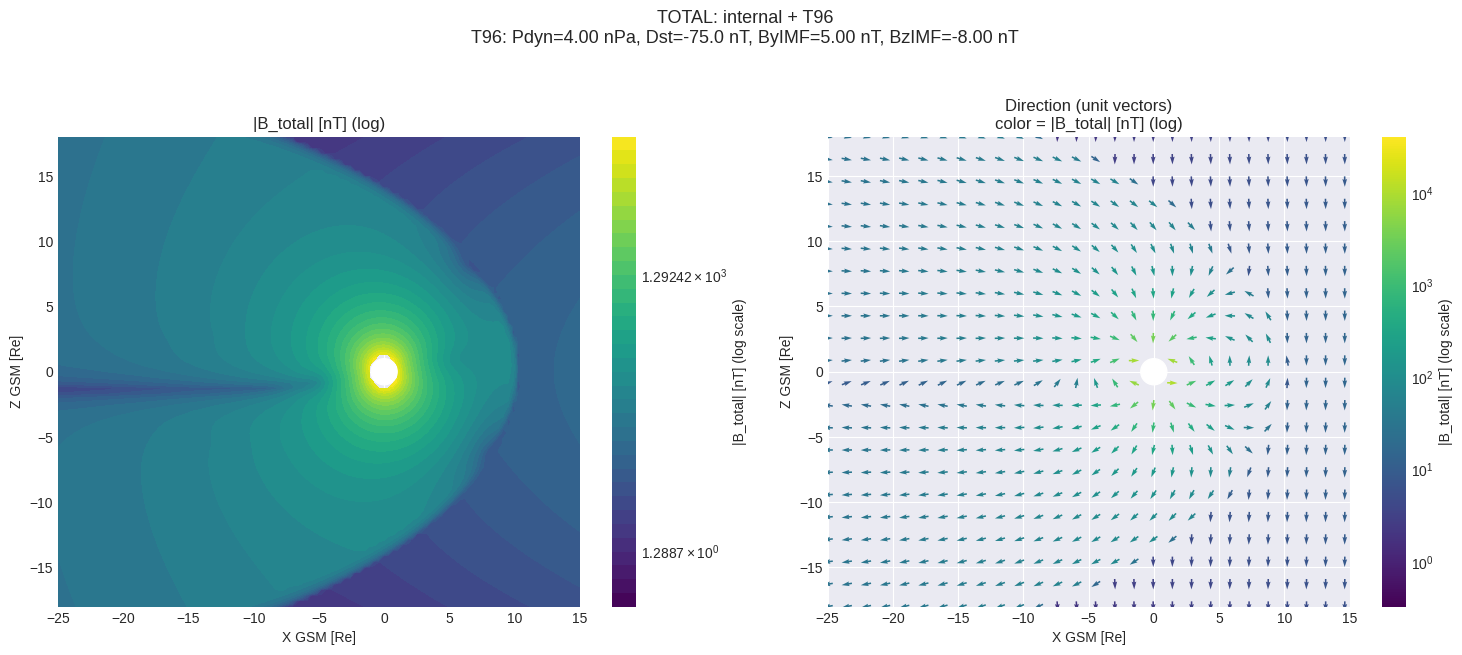

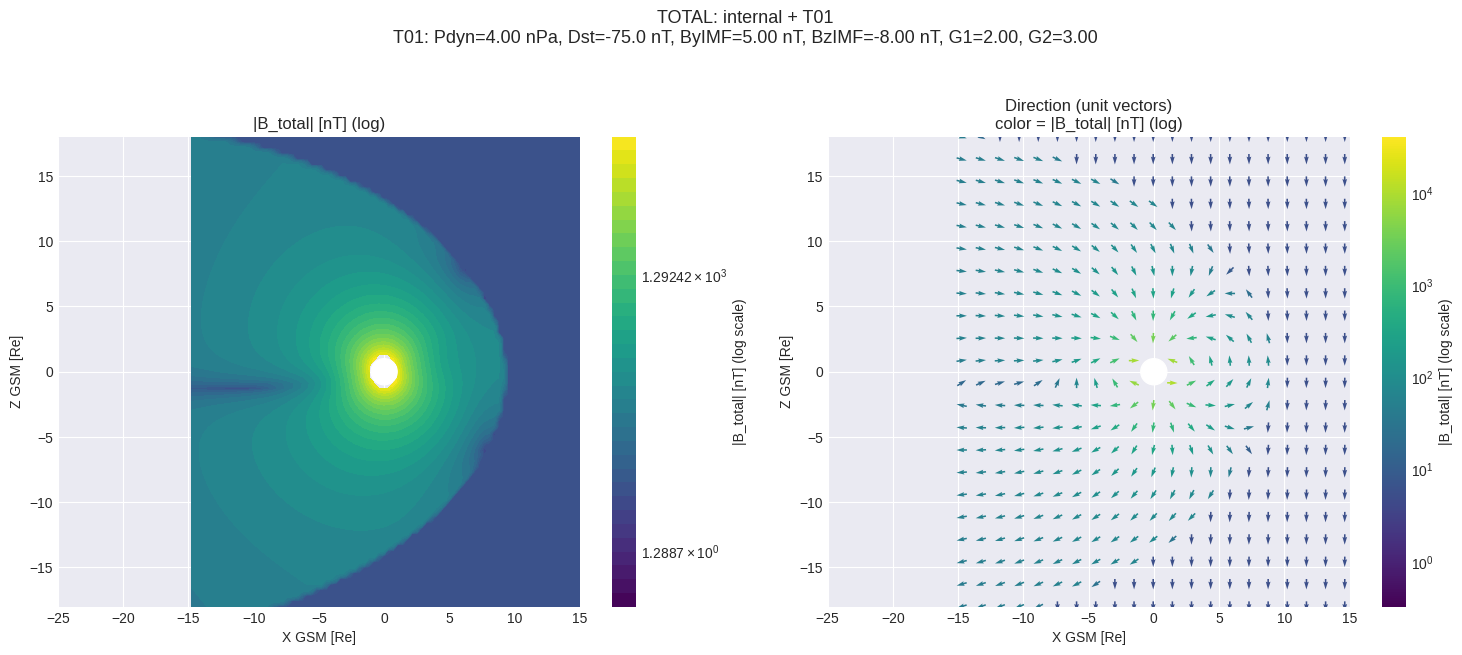

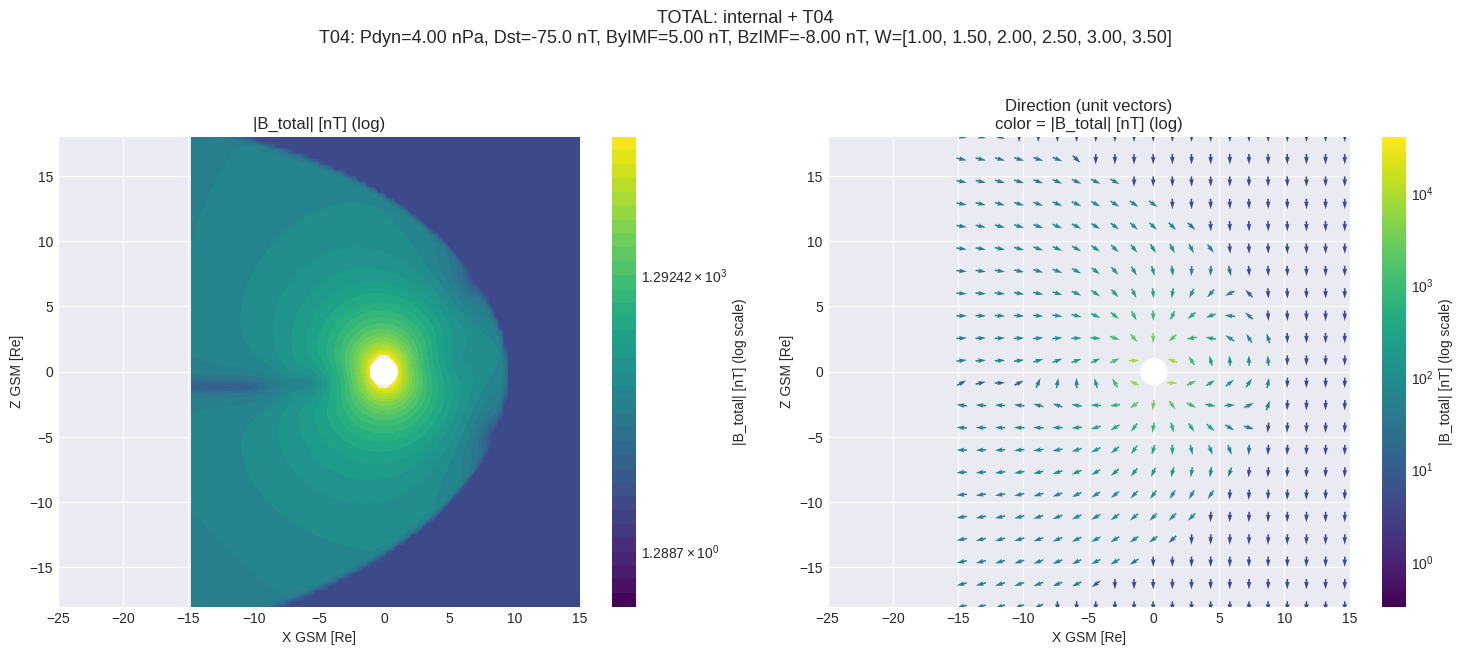

In [12]:
nx, nz = 110, 85
x_range = np.linspace(-25, 15, nx)
z_range = np.linspace(-18, 18, nz)
X_mer, Z_mer = np.meshgrid(x_range, z_range)
Y_mer = np.zeros_like(X_mer)

xf = X_mer.ravel()
yf = Y_mer.ravel()
zf = Z_mer.ravel()

internal_model_viz = "dipole"  # try "igrf"
igrf_coord_for_total = "gsm"

# Params (example)
iopt_t89 = 4

par_t96 = np.zeros(10, dtype=np.float64)
par_t96[0] = 4.0
par_t96[1] = -75.0
par_t96[2] = 5.0
par_t96[3] = -8.0

par_t01 = par_t96.copy()
par_t01[4] = 2.0
par_t01[5] = 3.0

par_t04 = par_t96.copy()
par_t04[4:10] = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

models_to_plot = [
    ("Internal only", None, None),
    ("TOTAL: internal + T89", "t89", iopt_t89),
    ("TOTAL: internal + T96", "t96", par_t96),
    ("TOTAL: internal + T01", "t01", par_t01),
    ("TOTAL: internal + T04", "t04", par_t04),
]

def format_params(ts_model, ts_params):
    if ts_model is None:
        return f"Internal={internal_model_viz} (IGRF coord={igrf_coord_for_total})"
    ts_model = ts_model.lower()
    if ts_model == "t89":
        iopt = int(ts_params)
        return f"T89 iopt={iopt} ({kp_values.get(iopt,'')})"
    p = np.asarray(ts_params, dtype=np.float64)
    base = f"Pdyn={p[0]:.2f} nPa, Dst={p[1]:.1f} nT, ByIMF={p[2]:.2f} nT, BzIMF={p[3]:.2f} nT"
    if ts_model == "t96":
        return f"T96: {base}"
    if ts_model == "t01":
        return f"T01: {base}, G1={p[4]:.2f}, G2={p[5]:.2f}"
    if ts_model == "t04":
        w = ", ".join([f"{v:.2f}" for v in p[4:10]])
        return f"T04: {base}, W=[{w}]"
    return base

# Compute internal field once
bx_int, by_int, bz_int = internal_field(internal_model_viz, xf, yf, zf,
                                        coord=igrf_coord_for_total,
                                        r_min=IGRF_RMIN, r_max=IGRF_RMAX_DEMO)

# For visualization clarity: mask inside Earth (r<1)
r = _norm3(xf, yf, zf)
inside = r < 1.0
bx_int = bx_int.copy(); by_int = by_int.copy(); bz_int = bz_int.copy()
bx_int[inside] = np.nan; by_int[inside] = np.nan; bz_int[inside] = np.nan

# First pass: compute all and set a common color scale
computed = []
all_mags = []

for title, ts_model, ts_params in models_to_plot:
    subtitle = format_params(ts_model, ts_params)

    if ts_model is None:
        bx, by, bz = bx_int, by_int, bz_int
    else:
        bx_e, by_e, bz_e = tsyganenko_external(ts_model, ts_params, ps, xf, yf, zf,
                                              enforce_domain=ENFORCE_TS_DOMAIN)
        bx, by, bz = bx_int + bx_e, by_int + by_e, bz_int + bz_e

    bmag = _norm3(bx, by, bz)
    Bmag2 = bmag.reshape(nz, nx)
    Bx2 = bx.reshape(nz, nx)
    Bz2 = bz.reshape(nz, nx)

    computed.append((title, subtitle, Bmag2, Bx2, Bz2))
    all_mags.append(Bmag2)

stack = np.stack(all_mags, axis=0)
pos = stack[np.isfinite(stack) & (stack > 0)]
bmin_global = np.nanmin(pos) if pos.size else 1e-3
bmax_global = np.nanmax(stack[np.isfinite(stack)]) if np.isfinite(stack).any() else 1.0

def plot_magnitude_quiver(X, Z, Bmag, Bx, Bz, title, subtitle, bmin, bmax):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f"{title}\n{subtitle}", fontsize=13, y=1.02)

    levels = np.logspace(np.log10(bmin), np.log10(bmax), 35)

    im = ax1.contourf(
        X, Z, Bmag, levels=levels, cmap="viridis",
        norm=matplotlib.colors.LogNorm(vmin=bmin, vmax=bmax)
    )
    ax1.set_xlabel("X GSM [Re]")
    ax1.set_ylabel("Z GSM [Re]")
    ax1.set_title("|B_total| [nT] (log)")
    ax1.set_aspect("equal")
    earth = plt.Circle((0, 0), 1, color="white", zorder=10)
    ax1.add_patch(earth)
    cbar = plt.colorbar(im, ax=ax1)
    cbar.set_label("|B_total| [nT] (log scale)")

    skip = 4
    Xs = X[::skip, ::skip]
    Zs = Z[::skip, ::skip]
    Bx_s = Bx[::skip, ::skip]
    Bz_s = Bz[::skip, ::skip]
    Bm_s = np.sqrt(Bx_s**2 + Bz_s**2)

    eps = 1e-12
    Ux = Bx_s / (Bm_s + eps)
    Uz = Bz_s / (Bm_s + eps)
    arrow_len = 0.8
    U = arrow_len * Ux
    V = arrow_len * Uz

    C = Bmag[::skip, ::skip]
    q = ax2.quiver(
        Xs, Zs, U, V, C, cmap="viridis",
        norm=matplotlib.colors.LogNorm(vmin=bmin, vmax=bmax),
        angles="xy", scale_units="xy", scale=1, pivot="mid", width=0.003
    )
    ax2.set_xlabel("X GSM [Re]")
    ax2.set_ylabel("Z GSM [Re]")
    ax2.set_title("Direction (unit vectors)\ncolor = |B_total| [nT] (log)")
    ax2.set_aspect("equal")
    earth2 = plt.Circle((0, 0), 1, color="white", zorder=10)
    ax2.add_patch(earth2)
    cbar2 = plt.colorbar(q, ax=ax2)
    cbar2.set_label("|B_total| [nT] (log scale)")

    ax1.set_xlim([x_range.min(), x_range.max()])
    ax1.set_ylim([z_range.min(), z_range.max()])
    ax2.set_xlim([x_range.min(), x_range.max()])
    ax2.set_ylim([z_range.min(), z_range.max()])

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

for title, subtitle, Bmag2, Bx2, Bz2 in computed:
    plot_magnitude_quiver(X_mer, Z_mer, Bmag2, Bx2, Bz2, title, subtitle, bmin_global, bmax_global)


## 10) Performance Analysis (External models)


Benchmark scalar vs vectorized for EXTERNAL field routines.

In [13]:
def benchmark_model(scalar_func, vector_func, params, ps, n_points, model_name):
    rng = np.random.default_rng(42)

    # Domain-aware sampling
    if model_name in ("T01", "T04"):
        x = rng.uniform(-15.0, 12.0, n_points)   # <-- FIX: keep within valid domain
    else:
        x = rng.uniform(-25.0, 12.0, n_points)

    y = rng.uniform(-15.0, 15.0, n_points)
    z = rng.uniform(-15.0, 15.0, n_points)
    # Warmup
    vector_func(params, ps, x[:5], y[:5], z[:5])

    # Scalar timing
    start = time.time()
    for i in range(n_points):
        scalar_func(params, ps, float(x[i]), float(y[i]), float(z[i]))
    t_scalar = time.time() - start

    # Vector timing
    start = time.time()
    vector_func(params, ps, x, y, z)
    t_vec = time.time() - start

    return dict(
        model=model_name,
        n_points=n_points,
        scalar_time=t_scalar,
        vector_time=t_vec,
        speedup=t_scalar / max(t_vec, 1e-12),
        vector_rate=n_points / max(t_vec, 1e-12),
    )

test_sizes = [10, 100, 1000, 10000]

parmod_storm = np.zeros(10, dtype=np.float64)
parmod_storm[0] = 3.0
parmod_storm[1] = -50.0
parmod_storm[2] = 0.0
parmod_storm[3] = -5.0

parmod_t01 = parmod_storm.copy()
parmod_t01[4] = 2.0
parmod_t01[5] = 3.0

parmod_t04 = parmod_storm.copy()
parmod_t04[4:10] = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

models = [
    ("T89", geopack.t89, geopack.t89_vectorized, 4),
    ("T96", geopack.t96, geopack.t96_vectorized, parmod_storm),
    ("T01", geopack.t01, geopack.t01_vectorized, parmod_t01),
    ("T04", geopack.t04, geopack.t04_vectorized, parmod_t04),
]

results = []
print("Performance benchmarks (external models)")
print("=" * 75)

for model_name, f_s, f_v, params in models:
    print(f"\n{model_name}")
    print(f"{'N':>10} {'scalar(s)':>12} {'vector(s)':>12} {'speedup':>10} {'rate(pts/s)':>14}")
    print("-" * 65)
    for n in test_sizes:
        r = benchmark_model(f_s, f_v, params, ps, n, model_name)
        results.append(r)
        print(f"{n:10d} {r['scalar_time']:12.4f} {r['vector_time']:12.4f} {r['speedup']:9.1f}x {r['vector_rate']:14.0f}")

df_perf = pd.DataFrame(results)
display(df_perf)


Performance benchmarks (external models)

T89
         N    scalar(s)    vector(s)    speedup    rate(pts/s)
-----------------------------------------------------------------
        10       0.0011       0.0005       2.1x          18551
       100       0.0125       0.0006      19.7x         157740
      1000       0.1139       0.0017      68.8x         604367


     10000       1.4394       0.0267      53.9x         374361

T96
         N    scalar(s)    vector(s)    speedup    rate(pts/s)
-----------------------------------------------------------------
        10       0.0327       0.0629       0.5x            159
       100       0.4165       0.1652       2.5x            605
      1000       2.7651       0.0856      32.3x          11677
     10000      36.3185       0.3077     118.0x          32496

T01
         N    scalar(s)    vector(s)    speedup    rate(pts/s)
-----------------------------------------------------------------
        10       0.0545       0.0512       1.1x            195
       100       0.5129       0.0628       8.2x           1592
      1000       5.2684       0.1423      37.0x           7025
     10000      47.7259       0.5319      89.7x          18802

T04
         N    scalar(s)    vector(s)    speedup    rate(pts/s)
-----------------------------------------------------------------
        10       0.0486       0

,model,n_points,scalar_time,vector_time,speedup,vector_rate
0,T89,10,0.001130,0.000539,2.096418,18550.659000
1,T89,100,0.012499,0.000634,19.715307,157739.902219
2,T89,1000,0.113859,0.001655,68.812536,604366.570605
3,T89,10000,1.439427,0.026712,53.886548,374361.070699
4,T96,10,0.032666,0.062884,0.519473,159.023332
5,T96,100,0.416525,0.165205,2.521267,605.310296
6,T96,1000,2.765111,0.085640,32.287535,11676.760365
7,T96,10000,36.318497,0.307730,118.020492,32495.973162
8,T01,10,0.054465,0.051231,1.063119,195.192852
9,T01,100,0.512863,0.062799,8.166771,1592.388676


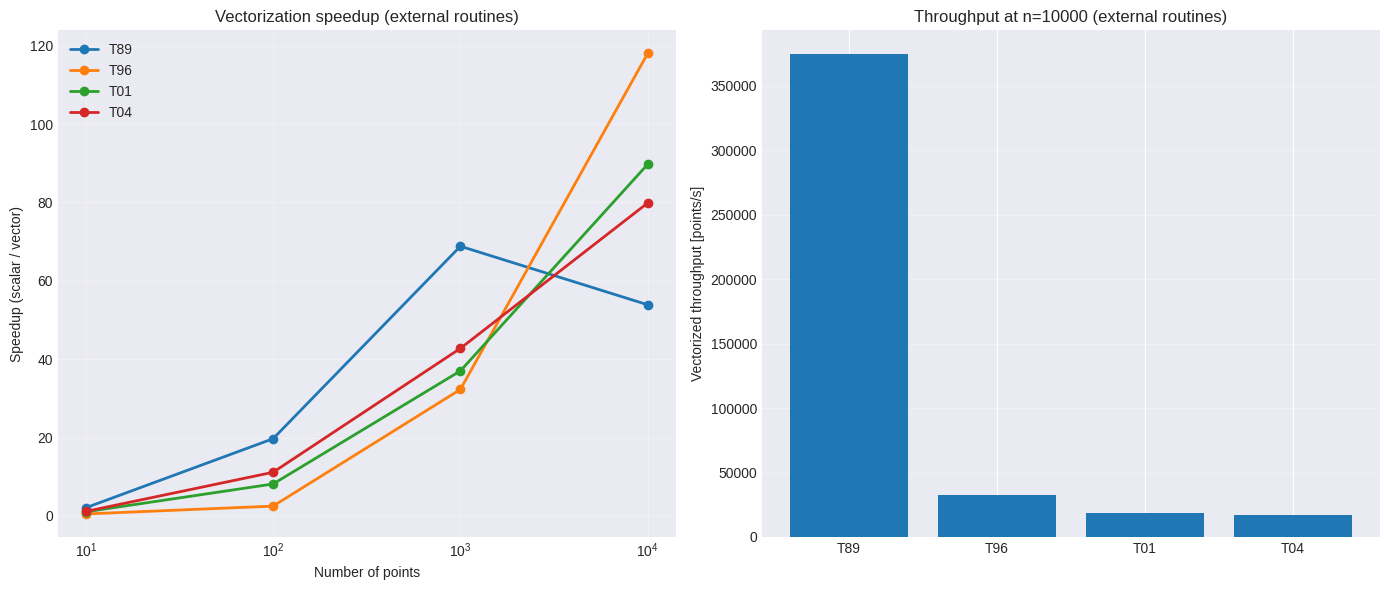

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for model_name in ["T89", "T96", "T01", "T04"]:
    sub = df_perf[df_perf["model"] == model_name].sort_values("n_points")
    ax1.semilogx(sub["n_points"], sub["speedup"], "o-", lw=2, label=model_name)

ax1.set_xlabel("Number of points")
ax1.set_ylabel("Speedup (scalar / vector)")
ax1.set_title("Vectorization speedup (external routines)")
ax1.grid(True, alpha=0.3)
ax1.legend()

n_compare = 10000
sub = df_perf[df_perf["n_points"] == n_compare].copy()
ax2.bar(sub["model"], sub["vector_rate"])
ax2.set_ylabel("Vectorized throughput [points/s]")
ax2.set_title(f"Throughput at n={n_compare} (external routines)")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()
